# Training Pipeline — BiLSTM + Bahdanau Attention Seq2Seq
## Ubuntu IRC Dialogue Corpus · Run 3 · Self-Contained Notebook

In [1]:
import subprocess, sys
_required = [('sentencepiece','sentencepiece'), ('sacrebleu','sacrebleu'), ('tqdm','tqdm'), ('rich','rich')]
for mod, pkg in _required:
    try: __import__(mod)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependencies OK')

Dependencies OK


In [2]:
import sys, os, json, math, time, random, warnings
from collections import Counter
from functools import partial
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
warnings.filterwarnings('ignore')

# venv sys.path (version-agnostic)
_pyver = f'python{sys.version_info.major}.{sys.version_info.minor}'
# Resolve project root first so venv path works
_nb_cwd = Path.cwd()
if (_nb_cwd / 'venv').exists():
    _project_root = _nb_cwd
elif (_nb_cwd.parent / 'venv').exists():
    _project_root = _nb_cwd.parent
else:
    _project_root = _nb_cwd
for _p in [str(_project_root / f'venv/lib/{_pyver}/site-packages'),
            str(_project_root / f'venv/lib64/{_pyver}/site-packages')]:
    if Path(_p).exists() and _p not in sys.path:
        sys.path.insert(0, _p)

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    matplotlib.use('Agg')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import sacrebleu as _sacrebleu
import sentencepiece as _spm

# Resolve project root regardless of notebook CWD
_nb_cwd = Path.cwd()
if (_nb_cwd / 'checkpoints').exists():
    BASE_DIR = _nb_cwd
elif (_nb_cwd.parent / 'checkpoints').exists():
    BASE_DIR = _nb_cwd.parent
else:
    BASE_DIR = _nb_cwd
os.chdir(BASE_DIR)
CKPT_DIR     = BASE_DIR / 'checkpoints'
ARTIFACT_DIR = BASE_DIR / 'artifacts'
VIZ_DIR      = BASE_DIR / 'notebooks' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    'attn_train':  '#1F4E79',
    'attn_val':    '#2E75B6',
    'attn_gen':    '#5BA3D9',
    'base_train':  '#70AD47',
    'base_val':    '#A9D18E',
    'base_gen':    '#C5DFA0',
    'tf_ratio':    '#002060',
    'lr':          '#9DC3E6',
    'bleu':        '#1F4E79',
    'f1':          '#2E75B6',
    'entropy':     '#1F4E79',
    'pred_len':    '#2E75B6',
    'active_tok':  '#9DC3E6',
    'grid':        '#E9EFF7',
    'bg':          '#FAFCFF',
    'annot':       '#C55A11',
    'highlight':   '#ED7D31',
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['bg'],
    'axes.grid':         True,
    'grid.color':        PALETTE['grid'],
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelcolor':   '#07182D',
    'xtick.color':       '#07182D',
    'ytick.color':       '#07182D',
    'text.color':        '#07182D',
    'font.family':       'DejaVu Sans',
    'font.size':         11,
})

print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.10.0+cu128 | CUDA: True
Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [3]:
# ── config.py inlined ────────────────────────────────────────────────────────

def _container_cpu_count() -> int:
    try:
        cpu_max = Path("/sys/fs/cgroup/cpu.max").read_text().strip()
        if cpu_max != "max":
            quota, period = cpu_max.split()
            return max(1, int(quota) // int(period))
    except (FileNotFoundError, ValueError):
        pass
    try:
        quota  = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_quota_us").read_text())
        period = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_period_us").read_text())
        if quota > 0:
            return max(1, math.ceil(quota / period))
    except (FileNotFoundError, ValueError):
        pass
    return max(1, os.cpu_count() or 1)

_CPU_COUNT = _container_cpu_count()
_WORKERS = max(1, _CPU_COUNT - 1)
if os.name == "nt":
    _WORKERS = min(4, _WORKERS)

_TOKENIZATION = {
    "vocab_size":            32000,
    "spm_vocab_size":        32000,
    "embed_dim":             300,
    "pad_idx":               0,
    "unk_idx":               1,
    "sos_idx":               2,
    "eos_idx":               3,
}

_ARCHITECTURE = {
    "enc_hidden_dim":        512,
    "dec_hidden_dim":        1024,
    "projection_dim":        512,
    "attn_dim":              256,
    "num_layers":            2,
    "shared_embeddings":     True,
    "dropout_embed":         0.3,
    "dropout_lstm":          0.5,
    "dropout_out":           0.4,
}

_TRAINING = {
    "learning_rate":         3e-4,
    "weight_decay":          1e-5,
    "max_grad_norm":         1.0,
    "batch_size":            256,
    "grad_accum_steps":      2,
    "num_epochs":            20,
    "amp_dtype":             "bfloat16",
    "patience":              6,
    "n_gen_samples":         512,
    "lr_min":                1e-5,
}

_TF_SCHEDULE = {
    "tf_schedule": {
        "phase1_end":       3,
        "phase1_tf":        1.0,
        "phase2_end":       12,
        "phase2_start_tf":  0.9,
        "phase2_end_tf":    0.5,
        "phase3_tf":        0.5,
    },
}

_LR_SCHEDULER = {
    "lr_scheduler_patience": 2,
    "lr_scheduler_factor":   0.5,
}

_LOSS = {
    "label_smoothing":       0.1,
}

_DATA = {
    "max_ctx_tokens":        256,
    "max_ctx_turns":         8,
    "max_resp_tokens":       50,
    "num_workers":           _WORKERS,
    "fasttext_workers":      _WORKERS,
}

_GPU_PROFILES: dict = {
    "A100": {
        "batch_size":       1024,
        "grad_accum_steps": 1,
        "n_gen_samples":    1024,
    },
    "3080": {
        "batch_size":       256,
        "grad_accum_steps": 2,
        "n_gen_samples":    512,
    },
}

def _select_gpu_profile() -> dict:
    try:
        if not torch.cuda.is_available():
            return {}
        gpu_name = torch.cuda.get_device_name(0)
        for key, profile in _GPU_PROFILES.items():
            if key in gpu_name:
                return profile
    except Exception:
        pass
    return {}

_gpu_profile: dict = _select_gpu_profile()

_NEW_DIR = BASE_DIR

_PATHS = {
    "artifact_dir":           str(_NEW_DIR / "artifacts"),
    "checkpoint_dir":         str(_NEW_DIR / "checkpoints"),
    "log_dir":                str(_NEW_DIR / "logs"),
    "spm_model_path":         str(_NEW_DIR / "artifacts" / "stage5_spm.model"),
    "embedding_matrix_path":  str(_NEW_DIR / "artifacts" / "stage8_embedding_matrix.npy"),
}

_REPRODUCIBILITY = {
    "seed": 42,
}

CONFIG: dict = {
    **_TOKENIZATION,
    **_ARCHITECTURE,
    **_TRAINING,
    **_TF_SCHEDULE,
    **_LR_SCHEDULER,
    **_LOSS,
    **_DATA,
    **_PATHS,
    **_REPRODUCIBILITY,
    **_gpu_profile,
}


def set_seed(seed: int = 42) -> None:
    import random as _random
    import numpy as _np
    _random.seed(seed)
    _np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    else:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_tf_ratio(epoch: int, config: dict) -> float:
    schedule = config["tf_schedule"]
    if epoch <= schedule["phase1_end"]:
        return schedule["phase1_tf"]
    if epoch <= schedule["phase2_end"]:
        phase2_start_epoch = schedule["phase1_end"] + 1
        tf_range = schedule["phase2_start_tf"] - schedule["phase2_end_tf"]
        step_range = schedule["phase2_end"] - phase2_start_epoch
        tf = schedule["phase2_start_tf"] - (epoch - phase2_start_epoch) * (
            tf_range / step_range
        )
        return tf
    return schedule["phase3_tf"]


print(json.dumps({k: v for k, v in CONFIG.items() if k not in ('tf_schedule',)}, indent=2, default=str))
print("tf_schedule:", json.dumps(CONFIG['tf_schedule'], indent=2))

{
  "vocab_size": 32000,
  "spm_vocab_size": 32000,
  "embed_dim": 300,
  "pad_idx": 0,
  "unk_idx": 1,
  "sos_idx": 2,
  "eos_idx": 3,
  "enc_hidden_dim": 512,
  "dec_hidden_dim": 1024,
  "projection_dim": 512,
  "attn_dim": 256,
  "num_layers": 2,
  "shared_embeddings": true,
  "dropout_embed": 0.3,
  "dropout_lstm": 0.5,
  "dropout_out": 0.4,
  "learning_rate": 0.0003,
  "weight_decay": 1e-05,
  "max_grad_norm": 1.0,
  "batch_size": 1024,
  "grad_accum_steps": 1,
  "num_epochs": 20,
  "amp_dtype": "bfloat16",
  "patience": 6,
  "n_gen_samples": 1024,
  "lr_min": 1e-05,
  "lr_scheduler_patience": 2,
  "lr_scheduler_factor": 0.5,
  "label_smoothing": 0.1,
  "max_ctx_tokens": 256,
  "max_ctx_turns": 8,
  "max_resp_tokens": 50,
  "num_workers": 7,
  "fasttext_workers": 7,
  "artifact_dir": "/opt/app-root/src/nlp-chatbot-project-v2.0/artifacts",
  "checkpoint_dir": "/opt/app-root/src/nlp-chatbot-project-v2.0/checkpoints",
  "log_dir": "/opt/app-root/src/nlp-chatbot-project-v2.0/logs",
  

In [4]:
# ── dataset.py inlined ───────────────────────────────────────────────────────

class BucketBatchSampler:
    def __init__(self, dataset, batch_size: int, bucket_size_factor: int = 100,
                 drop_last: bool = True, seed: int = 42) -> None:
        self.batch_size = batch_size
        self.drop_last = drop_last
        self.seed = seed
        self.bucket_size = batch_size * bucket_size_factor
        self.epoch = 0
        if hasattr(dataset, "dataset") and hasattr(dataset, "indices"):
            base = dataset.dataset
            self._lengths = [len(base.pairs[i]["ctx"]) for i in dataset.indices]
        else:
            self._lengths = [len(p["ctx"]) for p in dataset.pairs]
        self._n = len(self._lengths)

    def set_epoch(self, epoch: int) -> None:
        self.epoch = epoch

    def __iter__(self):
        import random as _rng
        rng = _rng.Random(self.seed + self.epoch)
        indices = list(range(self._n))
        rng.shuffle(indices)
        buckets = []
        for start in range(0, len(indices), self.bucket_size):
            bucket = indices[start: start + self.bucket_size]
            bucket.sort(key=lambda i: self._lengths[i])
            buckets.append(bucket)
        flat = [i for bucket in buckets for i in bucket]
        batches = [flat[i: i + self.batch_size]
                   for i in range(0, len(flat), self.batch_size)]
        if self.drop_last and batches and len(batches[-1]) < self.batch_size:
            batches.pop()
        rng.shuffle(batches)
        yield from batches

    def __len__(self) -> int:
        if self.drop_last:
            return self._n // self.batch_size
        return (self._n + self.batch_size - 1) // self.batch_size


class UbuntuPairDataset(Dataset):
    def __init__(self, jsonl_path: str, max_ctx_len: int, max_resp_len: int) -> None:
        self.pairs: List[Dict[str, List[int]]] = []
        with open(jsonl_path, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                record = json.loads(line)
                raw_ctx = record["ctx"]
                ctx  = raw_ctx[-max_ctx_len:] if len(raw_ctx) > max_ctx_len else raw_ctx
                resp = record["resp"][:max_resp_len]
                self.pairs.append({"ctx": ctx, "resp": resp})
        print(f"Loaded {len(self.pairs)} pairs from {jsonl_path}")

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int) -> Dict[str, List[int]]:
        return self.pairs[idx]


def _worker_init_fn(worker_id: int) -> None:
    import numpy as _np
    _np.random.seed(42 + worker_id)


def collate_fn(batch: List[Dict[str, List[int]]], pad_idx: int) -> Dict[str, torch.Tensor]:
    ctxs = [torch.tensor(item["ctx"], dtype=torch.long) for item in batch]
    resps = [torch.tensor(item["resp"], dtype=torch.long) for item in batch]
    src_lengths = torch.tensor([len(c) for c in ctxs], dtype=torch.long)
    trg_lengths = torch.tensor([len(r) for r in resps], dtype=torch.long)
    src = pad_sequence(ctxs, batch_first=True, padding_value=pad_idx)
    trg = pad_sequence(resps, batch_first=True, padding_value=pad_idx)
    return {"src": src, "src_lengths": src_lengths, "trg": trg, "trg_lengths": trg_lengths}


def build_dataloaders(artifact_dir: str, batch_size: int = 256, num_workers: int = 0,
                      max_ctx_len: int = 256, max_resp_len: int = 52, pad_idx: int = 0,
                      ) -> Tuple[DataLoader, DataLoader, DataLoader]:
    artifact_dir = Path(artifact_dir)
    _collate = partial(collate_fn, pad_idx=pad_idx)
    train_ds = UbuntuPairDataset(str(artifact_dir / "stage6_train_ids.jsonl"), max_ctx_len, max_resp_len)
    val_ds   = UbuntuPairDataset(str(artifact_dir / "stage6_val_ids.jsonl"),   max_ctx_len, max_resp_len)
    test_ds  = UbuntuPairDataset(str(artifact_dir / "stage6_test_ids.jsonl"),  max_ctx_len, max_resp_len)
    pin = torch.cuda.is_available()
    _common = dict(
        collate_fn=_collate, num_workers=num_workers, pin_memory=pin,
        worker_init_fn=_worker_init_fn if num_workers > 0 else None,
        persistent_workers=num_workers > 0,
        **({"prefetch_factor": 4} if num_workers > 0 else {}),
    )
    _bucket = BucketBatchSampler(train_ds, batch_size=batch_size, drop_last=True, seed=42)
    train_loader = DataLoader(train_ds, batch_sampler=_bucket, **_common)
    val_loader   = DataLoader(val_ds,  batch_size=batch_size, shuffle=False, drop_last=False, **_common)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False, **_common)
    return train_loader, val_loader, test_loader

print("Dataset classes defined.")

Dataset classes defined.


In [5]:
# ── models.py inlined ────────────────────────────────────────────────────────

def create_pretrained_embedding(matrix_path: str, pad_idx: int = 0, freeze: bool = False) -> nn.Embedding:
    matrix = np.load(matrix_path)
    vocab_size, embed_dim = matrix.shape
    embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=pad_idx)
    embedding.weight = nn.Parameter(torch.FloatTensor(matrix), requires_grad=(not freeze))
    embedding.weight.data[pad_idx].zero_()
    return embedding


class Encoder(nn.Module):
    def __init__(self, embedding: nn.Embedding, hidden_dim: int = 512, num_layers: int = 2,
                 dropout_embed: float = 0.3, dropout_lstm: float = 0.5, dropout_out: float = 0.4):
        super().__init__()
        self.embedding = embedding
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        embed_dim = embedding.embedding_dim
        self.embed_dropout = nn.Dropout(dropout_embed)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout_lstm if num_layers > 1 else 0.0)
        self.output_dropout = nn.Dropout(dropout_out)

    def forward(self, src: torch.LongTensor, src_lengths: torch.LongTensor
                ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        assert (src_lengths > 0).all(), f"Zero-length sequence in batch: {src_lengths.tolist()}"
        embedded = self.embed_dropout(self.embedding(src))
        packed = pack_padded_sequence(embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_outputs, (h_n, c_n) = self.lstm(packed)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True, total_length=src.size(1))
        outputs = self.output_dropout(outputs)
        return outputs, (h_n, c_n)


class EncoderDecoderBridge(nn.Module):
    def __init__(self, enc_hidden_dim: int, dec_hidden_dim: int, num_layers: int):
        super().__init__()
        self.num_layers = num_layers
        self.h_projection = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)
        self.c_projection = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)

    def _merge_bidir(self, states: torch.Tensor, proj: nn.Linear) -> torch.Tensor:
        fwd = states[0::2]
        bwd = states[1::2]
        merged = torch.cat([fwd, bwd], dim=2)
        return torch.tanh(proj(merged))

    def forward(self, h_n: torch.Tensor, c_n: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        return self._merge_bidir(h_n, self.h_projection), self._merge_bidir(c_n, self.c_projection)


class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim: int, dec_dim: int, attn_dim: int = 256):
        super().__init__()
        self.W_enc = nn.Linear(enc_dim,  attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_dim,  attn_dim, bias=False)
        self.v     = nn.Linear(attn_dim, 1,        bias=False)

    def forward(self, encoder_outputs: torch.Tensor, decoder_hidden: torch.Tensor,
                src_mask: Optional[torch.Tensor] = None,
                keys_proj: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        keys = keys_proj if keys_proj is not None else self.W_enc(encoder_outputs)
        query = self.W_dec(decoder_hidden).unsqueeze(1)
        energy = self.v(torch.tanh(keys + query)).squeeze(2)
        if src_mask is not None:
            energy = energy.masked_fill(src_mask, float("-inf"))
        attn_weights = F.softmax(energy, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights


class AttentionDecoder(nn.Module):
    def __init__(self, embedding: nn.Embedding, enc_hidden_dim: int, dec_hidden_dim: int,
                 vocab_size: int, projection_dim: int = 512, num_layers: int = 2,
                 dropout_embed: float = 0.3, dropout_lstm: float = 0.5, dropout_out: float = 0.4,
                 pad_idx: int = 0, attn_dim: int = 256):
        super().__init__()
        self.embedding = embedding
        self.enc_hidden_dim = enc_hidden_dim
        self.dec_hidden_dim = dec_hidden_dim
        self.num_layers = num_layers
        embed_dim = embedding.embedding_dim
        self.embed_dropout = nn.Dropout(dropout_embed)
        self.lstm_dropout  = nn.Dropout(dropout_lstm)
        self.out_dropout   = nn.Dropout(dropout_out)
        self.attention = BahdanauAttention(enc_dim=enc_hidden_dim, dec_dim=dec_hidden_dim, attn_dim=attn_dim)
        self.lstm = nn.LSTM(input_size=embed_dim + enc_hidden_dim, hidden_size=dec_hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout_lstm if num_layers > 1 else 0.0)
        self.projection = nn.Linear(dec_hidden_dim + enc_hidden_dim, projection_dim)
        self.fc_out     = nn.Linear(projection_dim, vocab_size)

    def forward_step(self, input_token, hidden, cell, encoder_outputs, context, src_mask, keys_proj=None):
        embedded = self.embed_dropout(self.embedding(input_token.unsqueeze(1)))
        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        lstm_out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        lstm_out = self.lstm_dropout(lstm_out.squeeze(1))
        new_context, step_attn = self.attention(encoder_outputs, hidden[-1], src_mask, keys_proj=keys_proj)
        combined = torch.cat([lstm_out, new_context], dim=1)
        projected = torch.tanh(self.projection(self.out_dropout(combined)))
        logits = self.fc_out(projected)
        return logits, hidden, cell, new_context, step_attn

    def forward(self, trg, encoder_outputs, h0, c0, src_mask, teacher_forcing_ratio: float = 1.0):
        batch_size = trg.size(0)
        trg_len    = trg.size(1)
        hidden, cell = h0, c0
        context = torch.zeros(batch_size, self.enc_hidden_dim, device=trg.device)
        keys_proj = self.attention.W_enc(encoder_outputs)
        logits_list = []
        input_token = trg[:, 0]
        for t in range(1, trg_len):
            logits, hidden, cell, context, _ = self.forward_step(
                input_token, hidden, cell, encoder_outputs, context, src_mask, keys_proj=keys_proj)
            logits_list.append(logits)
            if teacher_forcing_ratio >= 1.0:
                input_token = trg[:, t]
            elif teacher_forcing_ratio <= 0.0:
                input_token = logits.argmax(dim=1)
            else:
                tf_mask = torch.rand(logits.size(0), device=trg.device) < teacher_forcing_ratio
                input_token = torch.where(tf_mask, trg[:, t], logits.argmax(dim=1))
        return torch.stack(logits_list, dim=1)


class BaselineDecoder(nn.Module):
    def __init__(self, embedding: nn.Embedding, enc_hidden_dim: int, dec_hidden_dim: int,
                 vocab_size: int, projection_dim: int = 512, num_layers: int = 2,
                 dropout_embed: float = 0.3, dropout_lstm: float = 0.5, dropout_out: float = 0.4,
                 pad_idx: int = 0):
        super().__init__()
        self.embedding = embedding
        self.enc_hidden_dim = enc_hidden_dim
        self.dec_hidden_dim = dec_hidden_dim
        self.num_layers = num_layers
        embed_dim = embedding.embedding_dim
        self.embed_dropout = nn.Dropout(dropout_embed)
        self.lstm_dropout  = nn.Dropout(dropout_lstm)
        self.out_dropout   = nn.Dropout(dropout_out)
        self.lstm = nn.LSTM(input_size=embed_dim + enc_hidden_dim, hidden_size=dec_hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout_lstm if num_layers > 1 else 0.0)
        self.projection = nn.Linear(dec_hidden_dim + enc_hidden_dim, projection_dim)
        self.fc_out     = nn.Linear(projection_dim, vocab_size)

    def forward(self, trg, encoder_outputs, h0, c0, src_mask, teacher_forcing_ratio: float = 1.0):
        batch_size = trg.size(0)
        trg_len    = trg.size(1)
        hidden, cell = h0, c0
        context = encoder_outputs[:, -1, :]
        logits_list = []
        input_token = trg[:, 0]
        for t in range(1, trg_len):
            embedded = self.embed_dropout(self.embedding(input_token.unsqueeze(1)))
            lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
            lstm_out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
            lstm_out = self.lstm_dropout(lstm_out.squeeze(1))
            combined  = torch.cat([lstm_out, context], dim=1)
            projected = torch.tanh(self.projection(self.out_dropout(combined)))
            logits    = self.fc_out(projected)
            logits_list.append(logits)
            if teacher_forcing_ratio >= 1.0:
                input_token = trg[:, t]
            elif teacher_forcing_ratio <= 0.0:
                input_token = logits.argmax(dim=1)
            else:
                tf_mask = torch.rand(logits.size(0), device=trg.device) < teacher_forcing_ratio
                input_token = torch.where(tf_mask, trg[:, t], logits.argmax(dim=1))
        return torch.stack(logits_list, dim=1)

    def forward_step(self, input_token, hidden, cell, encoder_outputs, context, src_mask):
        fixed_ctx = encoder_outputs[:, -1, :]
        embedded = self.embed_dropout(self.embedding(input_token.unsqueeze(1)))
        lstm_input = torch.cat([embedded, fixed_ctx.unsqueeze(1)], dim=2)
        lstm_out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        lstm_out = self.lstm_dropout(lstm_out.squeeze(1))
        combined  = torch.cat([lstm_out, fixed_ctx], dim=1)
        projected = torch.tanh(self.projection(self.out_dropout(combined)))
        logits    = self.fc_out(projected)
        return logits, hidden, cell, fixed_ctx, None


class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, bridge: EncoderDecoderBridge, decoder, pad_idx: int = 0):
        super().__init__()
        self.encoder = encoder
        self.bridge  = bridge
        self.decoder = decoder
        self.pad_idx = pad_idx

    def forward(self, src, src_lengths, trg, teacher_forcing_ratio: float = 1.0):
        encoder_outputs, (h_n, c_n) = self.encoder(src, src_lengths)
        src_mask = (src == self.pad_idx)
        h0, c0 = self.bridge(h_n, c_n)
        return self.decoder(trg, encoder_outputs, h0, c0, src_mask, teacher_forcing_ratio)


def _init_weights(module: nn.Module) -> None:
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.LSTM):
        for name, param in module.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.zeros_(param)
                hidden_size = param.size(0) // 4
                param.data[hidden_size : 2 * hidden_size].fill_(1.0)


def build_model(model_type: str, config: dict, device: torch.device) -> Seq2Seq:
    if model_type not in ("attention", "baseline"):
        raise ValueError(f"model_type must be 'attention' or 'baseline', got {model_type!r}")
    embedding = create_pretrained_embedding(
        matrix_path=config["embedding_matrix_path"], pad_idx=config["pad_idx"], freeze=False)
    encoder = Encoder(embedding=embedding, hidden_dim=config["enc_hidden_dim"],
                      num_layers=config["num_layers"],
                      dropout_embed=config.get("dropout_embed", 0.3),
                      dropout_lstm=config.get("dropout_lstm",  0.5),
                      dropout_out=config.get("dropout_out",   0.4))
    bridge = EncoderDecoderBridge(enc_hidden_dim=config["enc_hidden_dim"],
                                   dec_hidden_dim=config["dec_hidden_dim"],
                                   num_layers=config["num_layers"])
    enc_hidden_total = config["enc_hidden_dim"] * 2
    decoder_kwargs = dict(embedding=embedding, enc_hidden_dim=enc_hidden_total,
                          dec_hidden_dim=config["dec_hidden_dim"], vocab_size=config["vocab_size"],
                          projection_dim=config["projection_dim"], num_layers=config["num_layers"],
                          pad_idx=config["pad_idx"],
                          dropout_embed=config.get("dropout_embed", 0.3),
                          dropout_lstm=config.get("dropout_lstm",  0.5),
                          dropout_out=config.get("dropout_out",   0.4))
    if model_type == "attention":
        decoder = AttentionDecoder(**decoder_kwargs, attn_dim=config.get("attn_dim", 256))
    else:
        decoder = BaselineDecoder(**decoder_kwargs)
    model = Seq2Seq(encoder=encoder, bridge=bridge, decoder=decoder, pad_idx=config["pad_idx"]).to(device)
    model.apply(_init_weights)
    def _count(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"[build_model] model_type     : {model_type}")
    print(f"[build_model] encoder params : {_count(encoder):,}")
    print(f"[build_model] bridge  params : {_count(bridge):,}")
    print(f"[build_model] decoder params : {_count(decoder):,}")
    print(f"[build_model] total   params : {_count(model):,}")
    return model

print("Model classes defined.")

Model classes defined.


In [6]:
# ── train.py utilities inlined ───────────────────────────────────────────────

def train_epoch(
    model: nn.Module, loader, optimizer: torch.optim.Optimizer,
    criterion: nn.Module, config: dict, device: torch.device,
    epoch: int, global_step: int,
    scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau = None,
) -> Tuple[float, float, int]:
    model.train()
    vocab_size: int = config["vocab_size"]
    grad_accum_steps: int = config["grad_accum_steps"]
    max_grad_norm: float = config["max_grad_norm"]
    _amp_dtype = getattr(torch, config.get("amp_dtype", "bfloat16"))
    tf_ratio: float = get_tf_ratio(epoch, config)
    total_loss = 0.0
    total_grad_norm = 0.0
    _accum_loss = 0.0
    n_updates = 0
    num_batches = len(loader)
    pbar = tqdm(enumerate(loader), total=num_batches, desc=f"  Epoch {epoch:3d} train",
                dynamic_ncols=True, unit="batch")
    optimizer.zero_grad(set_to_none=True)
    for batch_idx, batch in pbar:
        src = batch["src"].to(device, non_blocking=True)
        src_lengths = batch["src_lengths"].to(device, non_blocking=True)
        trg = batch["trg"].to(device, non_blocking=True)
        _device_type = device.type if hasattr(device, "type") else str(device).split(":")[0]
        with torch.amp.autocast(device_type=_device_type, dtype=_amp_dtype,
                                enabled=_device_type == "cuda"):
            output = model(src, src_lengths, trg, teacher_forcing_ratio=tf_ratio)
            loss = criterion(output.reshape(-1, vocab_size), trg[:, 1:].reshape(-1))
            scaled_loss = loss / grad_accum_steps
        scaled_loss.backward()
        _accum_loss += loss.item()
        is_last_batch = (batch_idx + 1) == num_batches
        should_step = ((batch_idx + 1) % grad_accum_steps == 0) or is_last_batch
        if should_step:
            grad_norm: float = torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm).item()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1
            _window = (batch_idx % grad_accum_steps) + 1
            total_loss += _accum_loss / _window
            _accum_loss = 0.0
            total_grad_norm += grad_norm
            n_updates += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}", grad_norm=f"{grad_norm:.3f}")
    avg_train_loss = total_loss / max(n_updates, 1)
    avg_grad_norm = total_grad_norm / max(n_updates, 1)
    return avg_train_loss, avg_grad_norm, global_step


def evaluate_loss(
    model: nn.Module, loader, criterion: nn.Module, device: torch.device,
    amp_dtype: torch.dtype = torch.bfloat16,
) -> Tuple[float, float]:
    model.eval()
    total_loss = 0.0
    n_batches = 0
    _device_type = device.type if hasattr(device, "type") else str(device).split(":")[0]
    with torch.no_grad():
        for batch in tqdm(loader, desc="  val", unit="batch", dynamic_ncols=True, leave=False):
            src = batch["src"].to(device, non_blocking=True)
            src_lengths = batch["src_lengths"].to(device, non_blocking=True)
            trg = batch["trg"].to(device, non_blocking=True)
            with torch.amp.autocast(device_type=_device_type, dtype=amp_dtype,
                                    enabled=_device_type == "cuda"):
                output = model(src, src_lengths, trg, teacher_forcing_ratio=1.0)
            vocab_size: int = output.size(-1)
            loss = criterion(output.reshape(-1, vocab_size), trg[:, 1:].reshape(-1))
            total_loss += loss.item()
            n_batches += 1
    avg_loss = total_loss / max(n_batches, 1)
    return avg_loss, math.exp(min(avg_loss, 20))


def evaluate_generation(
    model: nn.Module, loader, device: torch.device,
    amp_dtype: torch.dtype = torch.bfloat16,
    eos_idx: int = 3, pad_idx: int = 0,
    sp_model=None, n_gen_samples: int = 1024,
) -> Tuple[float, float, float, float, float]:
    model.eval()
    total_ce_sum = 0.0
    total_pred_len = 0.0
    total_active_tokens = 0
    n_batches = 0
    n_seen = 0
    hypotheses: List[str] = []
    references: List[str] = []
    _device_type = device.type if hasattr(device, "type") else str(device).split(":")[0]
    _special = {0, 1, 2, eos_idx, pad_idx}
    with torch.no_grad():
        for batch in tqdm(loader, desc="  gen", unit="batch", dynamic_ncols=True, leave=False):
            if n_seen >= n_gen_samples:
                break
            src = batch["src"].to(device, non_blocking=True)
            src_lengths = batch["src_lengths"].to(device, non_blocking=True)
            trg = batch["trg"].to(device, non_blocking=True)
            with torch.amp.autocast(device_type=_device_type, dtype=amp_dtype,
                                    enabled=_device_type == "cuda"):
                output = model(src, src_lengths, trg, teacher_forcing_ratio=0.0)
            vocab_size: int = output.size(-1)
            preds = output.argmax(-1)
            eos_cumsum = preds.eq(eos_idx).long().cumsum(dim=1)
            active = (eos_cumsum <= 1) & trg[:, 1:].ne(pad_idx)
            per_tok = F.cross_entropy(output.reshape(-1, vocab_size), trg[:, 1:].reshape(-1),
                                      ignore_index=pad_idx, reduction="none")
            n_active = active.reshape(-1).sum().clamp(min=1)
            total_ce_sum += per_tok[active.reshape(-1)].sum().item()
            total_active_tokens += n_active.item()
            has_eos   = preds.eq(eos_idx).any(dim=1)
            first_eos = preds.eq(eos_idx).long().argmax(dim=1).add(1)
            full_len  = torch.full_like(first_eos, preds.size(1))
            lengths   = torch.where(has_eos, first_eos, full_len)
            total_pred_len += lengths.float().mean().item()
            if sp_model is not None:
                for i in range(preds.size(0)):
                    hyp_ids = preds[i].cpu().tolist()
                    ref_ids = trg[i, 1:].cpu().tolist()
                    try: hyp_ids = hyp_ids[:hyp_ids.index(eos_idx)]
                    except ValueError: pass
                    try: ref_ids = ref_ids[:ref_ids.index(eos_idx)]
                    except ValueError: pass
                    hyp_ids = [t for t in hyp_ids if t not in _special]
                    ref_ids = [t for t in ref_ids  if t not in _special]
                    hypotheses.append(sp_model.decode(hyp_ids))
                    references.append(sp_model.decode(ref_ids))
            n_batches += 1
            n_seen += preds.size(0)
    avg_gen_loss = total_ce_sum / max(total_active_tokens, 1)
    avg_pred_len = total_pred_len / max(n_batches, 1)
    avg_active_tokens = total_active_tokens / max(n_batches, 1)
    bleu = _sacrebleu.corpus_bleu(hypotheses, [references], force=True).score if hypotheses else 0.0
    tp_total = hyp_total = ref_total = 0
    for hyp_str, ref_str in zip(hypotheses, references):
        hyp_toks = hyp_str.split()
        ref_toks = ref_str.split()
        common   = sum((Counter(hyp_toks) & Counter(ref_toks)).values())
        tp_total  += common
        hyp_total += len(hyp_toks)
        ref_total += len(ref_toks)
    p = tp_total / max(hyp_total, 1)
    r = tp_total / max(ref_total, 1)
    token_f1 = (2 * p * r / (p + r) * 100) if (p + r) > 0 else 0.0
    return avg_gen_loss, avg_pred_len, bleu, token_f1, avg_active_tokens


def log_decoded_samples(model, loader, device, sp_model, model_type, epoch,
                         n_samples=10, pad_idx=0, eos_idx=3,
                         amp_dtype=torch.bfloat16) -> None:
    if sp_model is None:
        return
    model.eval()
    _device_type = device.type if hasattr(device, "type") else str(device).split(":")[0]
    _special = {pad_idx, 0, 1, 2, eos_idx}
    samples_collected = 0
    rows = []
    from torch.utils.data import DataLoader as _DL
    _bs = loader.batch_size or 32
    _cf = getattr(loader, "collate_fn", None)
    safe_loader = _DL(loader.dataset, batch_size=_bs, shuffle=False,
                      num_workers=0, collate_fn=_cf, pin_memory=False)
    with torch.no_grad():
        for batch in safe_loader:
            if samples_collected >= n_samples:
                break
            src = batch["src"].to(device, non_blocking=True)
            src_lengths = batch["src_lengths"].to(device, non_blocking=True)
            trg = batch["trg"].to(device, non_blocking=True)
            with torch.amp.autocast(device_type=_device_type, dtype=amp_dtype,
                                    enabled=_device_type == "cuda"):
                output = model(src, src_lengths, trg, teacher_forcing_ratio=0.0)
            preds = output.argmax(-1)
            for i in range(min(preds.size(0), n_samples - samples_collected)):
                src_ids = src[i].cpu().tolist()
                hyp_ids = preds[i].cpu().tolist()
                ref_ids = trg[i, 1:].cpu().tolist()
                def _clean(ids):
                    try: ids = ids[:ids.index(eos_idx)]
                    except ValueError: pass
                    return [t for t in ids if t not in _special]
                rows.append((sp_model.decode(_clean(src_ids)),
                             sp_model.decode(_clean(ref_ids)),
                             sp_model.decode(_clean(hyp_ids))))
                samples_collected += 1
    sep = "─" * 80
    print(f"\n  [{model_type}] Decoded samples — epoch {epoch}")
    print(f"  {sep}")
    for src_str, ref_str, hyp_str in rows:
        print(f"  Src : {src_str[:75]}")
        print(f"  Ref : {ref_str[:75]}")
        print(f"  Hyp : {hyp_str[:75]}")
        print(f"  {sep}")


_PROBE_QUESTIONS = [
    ("pkg-1",  "how do i install a package on ubuntu"),
    ("pkg-2",  "apt-get says unable to lock the administration directory"),
    ("pkg-3",  "how do i remove a package and all its config files"),
    ("pkg-4",  "how do i upgrade only one package without upgrading everything"),
    ("fs-1",   "my disk is full and i cant write any new files"),
    ("fs-2",   "how do i find which directory is using the most space"),
    ("fs-3",   "i get permission denied when i try to edit a file in etc"),
    ("fs-4",   "how do i mount a usb drive from the command line"),
    ("net-1",  "my wifi dropped after the last update and wont reconnect"),
    ("net-2",  "ssh says connection refused when i try to connect to my server"),
    ("net-3",  "how do i check which ports are open on my machine"),
    ("sys-1",  "my system is very slow and the fan is spinning loudly"),
    ("sys-2",  "how do i kill a process that is not responding"),
    ("sys-3",  "how do i add a new user and give them sudo access"),
    ("err-1",  "i broke my grub and the system wont boot anymore"),
    ("err-2",  "dpkg is in a broken state and apt wont run"),
]


def log_probe_responses(model, device, sp_model, model_type, epoch, config,
                         amp_dtype=torch.bfloat16) -> None:
    if sp_model is None:
        return
    model.eval()
    _device_type = device.type if hasattr(device, "type") else str(device).split(":")[0]
    _pad  = config.get("pad_idx", 0)
    _eos  = config.get("eos_idx", 3)
    _max_src = config.get("max_ctx_tokens", 50)
    _max_tgt = config.get("max_resp_tokens", 50)
    _special = {_pad, 1, 2, _eos}
    def _encode(text):
        ids = sp_model.encode(text.strip(), out_type=int)[:_max_src]
        src = torch.tensor([ids], dtype=torch.long, device=device)
        lengths = torch.tensor([len(ids)], dtype=torch.long, device=device)
        return src, lengths
    def _decode_ids(ids):
        try: ids = ids[:ids.index(_eos)]
        except ValueError: pass
        return sp_model.decode([t for t in ids if t not in _special])
    sep  = "─" * 80
    sep2 = "┄" * 80
    print(f"\n  [{model_type}] Probe responses — epoch {epoch}")
    print(f"  {sep}")
    with torch.no_grad():
        prev_group = None
        for tag, question in _PROBE_QUESTIONS:
            group = tag.split("-")[0]
            if prev_group is not None and group != prev_group:
                print(f"  {sep2}")
            prev_group = group
            src, src_lengths = _encode(question)
            trg_seed = torch.full((1, _max_tgt + 2), _pad, dtype=torch.long, device=device)
            trg_seed[0, 0] = config.get("sos_idx", 2)
            with torch.amp.autocast(device_type=_device_type, dtype=amp_dtype,
                                    enabled=_device_type == "cuda"):
                output = model(src, src_lengths, trg_seed, teacher_forcing_ratio=0.0)
            hyp_ids = output.argmax(-1)[0].cpu().tolist()
            hyp_str = _decode_ids(hyp_ids)
            print(f"  [{tag:5s}] Q: {question}")
            print(f"         A: {hyp_str[:120] or '(empty)'}")
    print(f"  {sep}\n")


def compute_attention_entropy(
    model: nn.Module, loader, device: torch.device,
    n_samples: int = 256, eos_idx: int = 3, pad_idx: int = 0,
    amp_dtype: torch.dtype = torch.bfloat16,
) -> Optional[float]:
    if not hasattr(model.decoder, "attention"):
        return None
    model.eval()
    _device_type = device.type if hasattr(device, "type") else str(device).split(":")[0]
    total_entropy = 0.0
    n_steps = 0
    n_seen = 0
    eps = 1e-10
    from torch.utils.data import DataLoader as _DL
    _bs = loader.batch_size or 32
    _cf = getattr(loader, "collate_fn", None)
    safe_loader = _DL(loader.dataset, batch_size=_bs, shuffle=False,
                      num_workers=0, collate_fn=_cf, pin_memory=False)
    with torch.no_grad():
        for batch in safe_loader:
            if n_seen >= n_samples:
                break
            src = batch["src"].to(device, non_blocking=True)
            src_lengths = batch["src_lengths"].to(device, non_blocking=True)
            trg = batch["trg"].to(device, non_blocking=True)
            with torch.amp.autocast(device_type=_device_type, dtype=amp_dtype,
                                    enabled=_device_type == "cuda"):
                encoder_outputs, (h_n, c_n) = model.encoder(src, src_lengths)
                src_mask = (src == pad_idx)
                h0, c0   = model.bridge(h_n, c_n)
                keys_proj = model.decoder.attention.W_enc(encoder_outputs)
            context     = torch.zeros(src.size(0), encoder_outputs.size(-1), device=device)
            hidden, cell = h0, c0
            input_token  = trg[:, 0]
            for t in range(1, min(trg.size(1), 40)):
                with torch.amp.autocast(device_type=_device_type, dtype=amp_dtype,
                                        enabled=_device_type == "cuda"):
                    logits, hidden, cell, context, attn_weights = model.decoder.forward_step(
                        input_token, hidden, cell, encoder_outputs, context,
                        src_mask, keys_proj=keys_proj,
                    )
                if attn_weights is not None:
                    ent = -(attn_weights * (attn_weights + eps).log()).sum(dim=-1).mean()
                    total_entropy += ent.item()
                    n_steps += 1
                input_token = logits.argmax(dim=-1)
            n_seen += src.size(0)
    return total_entropy / max(n_steps, 1)


def build_optimizer_and_scheduler(model, config):
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=config["learning_rate"],
                                   weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=config.get("lr_scheduler_factor", 0.5),
        patience=config.get("lr_scheduler_patience", 3),
        min_lr=config.get("lr_min", 1e-5))
    return optimizer, scheduler

print("Training utilities defined.")

Training utilities defined.


In [7]:
_ATTN_HIST  = CKPT_DIR / 'attention_history.json'
_BASE_HIST   = CKPT_DIR / 'baseline_history.json'
_ATTN_CKPT   = CKPT_DIR / 'attention_best.pt'
_BASE_CKPT   = CKPT_DIR / 'baseline_best.pt'

TRAINING_DONE = _ATTN_HIST.exists() and _BASE_HIST.exists()

if TRAINING_DONE:
    print("\u2713 Training history found \u2014 loading results (skipping training)")
    attn_h = json.load(open(_ATTN_HIST))
    base_h = json.load(open(_BASE_HIST))
    N_EPOCHS = len(attn_h['train_loss'])
    print(f"  Attention: {N_EPOCHS} epochs | best val: {min(attn_h['val_loss']):.4f}")
    print(f"  Baseline:  {len(base_h['train_loss'])} epochs | best val: {min(base_h['val_loss']):.4f}")
else:
    print("\u2717 No training history found \u2014 will train from scratch")
    print("  This will take several hours on GPU. Set TRAINING_DONE=True to skip.")

✓ Training history found — loading results (skipping training)
  Attention: 20 epochs | best val: 5.0898
  Baseline:  20 epochs | best val: 5.1305


In [8]:
if TRAINING_DONE:
    # ── REPLAY MODE: print epoch log from history ──────────────────────────
    print(f"\n{'='*80}")
    print(f"  TRAINING REPLAY \u2014 {N_EPOCHS} epochs")
    print(f"{'='*80}")
    print(f"\n  {'Ep':>3}  {'TF':>5}  {'LR':>10}  {'Train':>8}  {'Val':>8}  {'Gen':>8}  {'BLEU':>6}  {'F1':>6}")
    print(f"  {'-'*70}")

    for i in range(N_EPOCHS):
        ep  = i + 1
        tf  = attn_h['tf_ratios'][i]
        lr  = attn_h['lrs'][i]
        tl  = attn_h['train_loss'][i]
        vl  = attn_h['val_loss'][i]
        gl  = attn_h['gen_loss'][i]
        bl  = attn_h['bleu'][i]
        f1  = attn_h['token_f1'][i]
        ppl = math.exp(vl)
        ent_raw = attn_h['attn_entropy'][i]
        ent = ent_raw if ent_raw is not None else 0.0
        marker = '\u2713' if vl == min(attn_h['val_loss']) else ' '
        print(f"  Ep {ep:>2}/{N_EPOCHS}  TF:{tf:.2f}  Val:{vl:.4f}  PPL:{ppl:7.2f}  "
              f"BLEU:{bl:.2f}  F1:{f1:.2f}  Len:{attn_h['avg_pred_len'][i]:.1f}  "
              f"LR:{lr:.2e}  Ent:{ent:.3f}  {marker}")

    best_ep = attn_h['val_loss'].index(min(attn_h['val_loss'])) + 1
    print(f"\n  Best checkpoint: epoch {best_ep} | val_loss={min(attn_h['val_loss']):.4f}")
    print(f"  Checkpoint: {_ATTN_CKPT}")

else:
    # ── TRAINING MODE: run actual training ─────────────────────────────────
    set_seed(CONFIG['seed'])

    print("Loading data...")
    train_loader, val_loader, test_loader = build_dataloaders(
        artifact_dir=CONFIG['artifact_dir'],
        batch_size=CONFIG['batch_size'],
        num_workers=CONFIG['num_workers'],
        max_ctx_len=CONFIG['max_ctx_tokens'],
        max_resp_len=CONFIG['max_resp_tokens'] + 2,
        pad_idx=CONFIG['pad_idx'],
    )

    attn_h = {k: [] for k in ['train_loss','val_loss','gen_loss','bleu','token_f1',
                                'avg_pred_len','avg_active_tokens','attn_entropy','tf_ratios','lrs']}
    base_h = {k: [] for k in ['train_loss','val_loss','gen_loss','bleu','token_f1',
                                'avg_pred_len','avg_active_tokens','attn_entropy','tf_ratios','lrs']}

    for model_type, history in [('attention', attn_h), ('baseline', base_h)]:
        print(f"\n{'='*60}\n  TRAINING: {model_type}\n{'='*60}")
        model = build_model(model_type, CONFIG, device)
        optimizer, scheduler = build_optimizer_and_scheduler(model, CONFIG)
        criterion = nn.CrossEntropyLoss(
            ignore_index=CONFIG['pad_idx'],
            label_smoothing=CONFIG['label_smoothing']
        )
        sp = _spm.SentencePieceProcessor()
        sp.Load(CONFIG['spm_model_path'])

        best_val = float('inf')
        global_step = 0
        CKPT_DIR.mkdir(exist_ok=True)

        for epoch in range(1, CONFIG['num_epochs'] + 1):
            tf = get_tf_ratio(epoch, CONFIG)
            train_loss, _, global_step = train_epoch(
                model, train_loader, optimizer, criterion, CONFIG, device, epoch, global_step
            )
            val_loss, _ = evaluate_loss(model, val_loader, criterion, device)
            gen_loss, avg_len, bleu, f1, n_active = evaluate_generation(
                model, val_loader, device,
                sp_model=sp, n_gen_samples=CONFIG['n_gen_samples'],
                eos_idx=CONFIG['eos_idx'], pad_idx=CONFIG['pad_idx'],
            )

            scheduler.step(val_loss)
            lr = optimizer.param_groups[0]['lr']

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['gen_loss'].append(gen_loss)
            history['bleu'].append(bleu)
            history['token_f1'].append(f1)
            history['avg_pred_len'].append(avg_len)
            history['avg_active_tokens'].append(n_active)
            history['tf_ratios'].append(tf)
            history['lrs'].append(lr)

            ent = None
            if model_type == 'attention':
                ent = compute_attention_entropy(model, val_loader, device,
                                                eos_idx=CONFIG['eos_idx'], pad_idx=CONFIG['pad_idx'])
            history['attn_entropy'].append(ent)

            ppl = math.exp(val_loss)
            print(f"  Ep {epoch:>2}/{CONFIG['num_epochs']}  TF:{tf:.2f}  "
                  f"Val:{val_loss:.4f}  PPL:{ppl:.2f}  BLEU:{bleu:.2f}  LR:{lr:.2e}")

            if val_loss < best_val:
                best_val = val_loss
                ckpt_name = f'{model_type}_best.pt'
                torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch,
                            'val_loss': val_loss, 'config': CONFIG},
                           CKPT_DIR / ckpt_name)
                print(f"    \u2713 Saved {ckpt_name}")

        hist_name = f'{model_type}_history.json'
        json.dump(history, open(CKPT_DIR / hist_name, 'w'), indent=2)
        print(f"  History saved: {hist_name}")

    N_EPOCHS = CONFIG['num_epochs']
    TRAINING_DONE = True
    print("\nTraining complete!")


  TRAINING REPLAY — 20 epochs

   Ep     TF          LR     Train       Val       Gen    BLEU      F1
  ----------------------------------------------------------------------
  Ep  1/20  TF:1.00  Val:6.0234  PPL: 413.00  BLEU:0.71  F1:13.91  Len:12.9  LR:3.00e-04  Ent:2.517   
  Ep  2/20  TF:1.00  Val:5.5461  PPL: 256.23  BLEU:0.44  F1:12.53  Len:10.8  LR:3.00e-04  Ent:1.999   
  Ep  3/20  TF:1.00  Val:5.3008  PPL: 200.49  BLEU:0.44  F1:12.87  Len:11.4  LR:3.00e-04  Ent:2.050   
  Ep  4/20  TF:0.90  Val:5.2148  PPL: 183.98  BLEU:0.72  F1:14.55  Len:11.3  LR:3.00e-04  Ent:2.169   
  Ep  5/20  TF:0.85  Val:5.1602  PPL: 174.19  BLEU:0.78  F1:14.76  Len:10.7  LR:3.00e-04  Ent:2.027   
  Ep  6/20  TF:0.80  Val:5.1289  PPL: 168.83  BLEU:1.07  F1:14.46  Len:11.1  LR:3.00e-04  Ent:2.100   
  Ep  7/20  TF:0.75  Val:5.1133  PPL: 166.21  BLEU:0.86  F1:15.97  Len:9.9  LR:3.00e-04  Ent:2.100   
  Ep  8/20  TF:0.70  Val:5.1094  PPL: 165.57  BLEU:0.65  F1:15.83  Len:9.8  LR:3.00e-04  Ent:2.107   
  

## Training Results

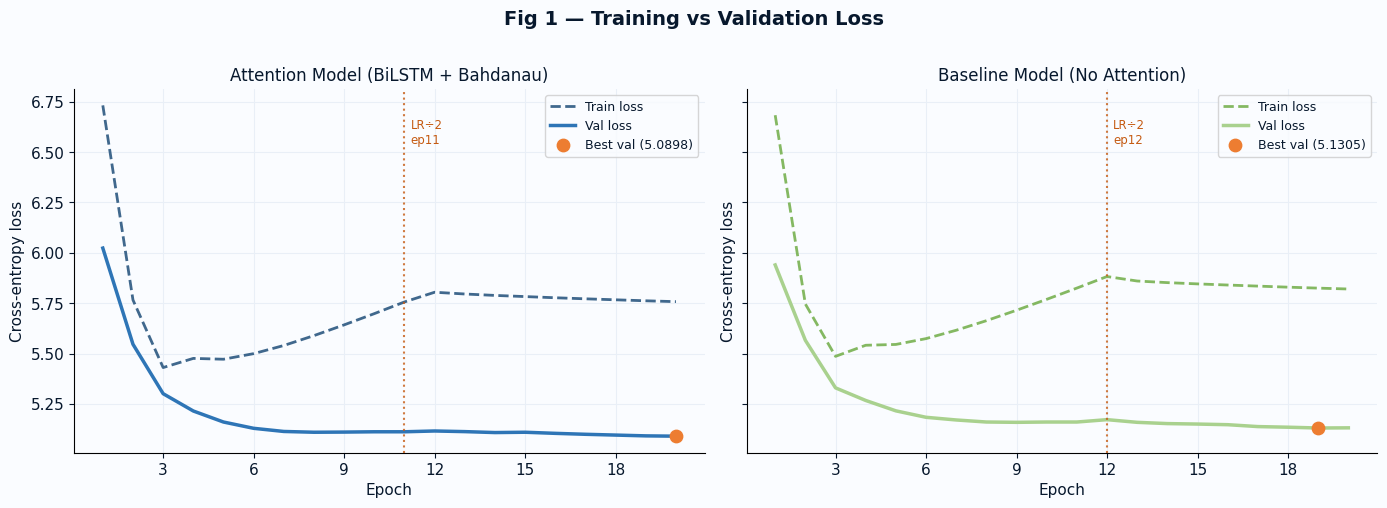

Saved: train_fig1_loss.png


In [9]:
# Fig 1 — Train / Val Loss (two panels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Fig 1 \u2014 Training vs Validation Loss', fontsize=14, fontweight='bold', y=1.01)

epochs = list(range(1, len(attn_h['train_loss'])+1))

for ax, h, title, c_train, c_val in [
    (axes[0], attn_h, 'Attention Model (BiLSTM + Bahdanau)', PALETTE['attn_train'], PALETTE['attn_val']),
    (axes[1], base_h, 'Baseline Model (No Attention)',       PALETTE['base_train'], PALETTE['base_val']),
]:
    ax.plot(epochs, h['train_loss'], color=c_train, lw=2,   ls='--', label='Train loss', alpha=0.85)
    ax.plot(epochs, h['val_loss'],   color=c_val,   lw=2.5, ls='-',  label='Val loss')

    best_i = h['val_loss'].index(min(h['val_loss']))
    ax.scatter([best_i+1], [h['val_loss'][best_i]], color=PALETTE['highlight'], s=80, zorder=5,
               label=f'Best val ({h["val_loss"][best_i]:.4f})')

    lrs = h['lrs']
    lr_drop_ep = next((i+1 for i in range(1, len(lrs)) if lrs[i] < lrs[i-1]*0.6), None)
    if lr_drop_ep:
        ax.axvline(lr_drop_ep, color=PALETTE['annot'], lw=1.5, ls=':', alpha=0.8)
        ylim = ax.get_ylim()
        ypos = ylim[0] + (ylim[1]-ylim[0])*0.85
        ax.text(lr_drop_ep+0.2, ypos, f'LR\u00f72\nep{lr_drop_ep}',
                color=PALETTE['annot'], fontsize=8.5)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(VIZ_DIR / 'train_fig1_loss.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print("Saved: train_fig1_loss.png")

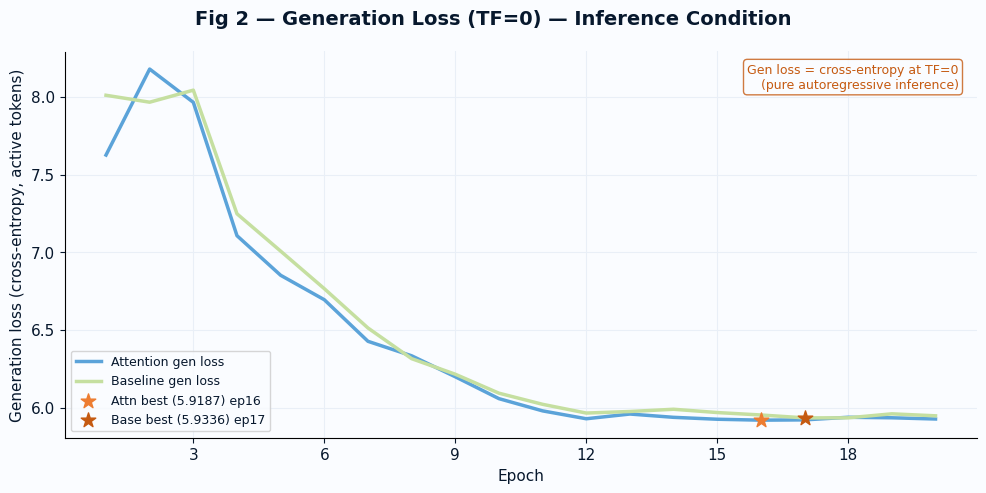

Saved: train_fig2_gen_loss.png


In [10]:
# Fig 2 — Gen Loss (TF=0 evaluation)
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Fig 2 \u2014 Generation Loss (TF=0) — Inference Condition', fontsize=14, fontweight='bold')

epochs = list(range(1, len(attn_h['gen_loss'])+1))
ax.plot(epochs, attn_h['gen_loss'], color=PALETTE['attn_gen'], lw=2.5, label='Attention gen loss')
ax.plot(epochs, base_h['gen_loss'], color=PALETTE['base_gen'], lw=2.5, label='Baseline gen loss')

best_a = attn_h['gen_loss'].index(min(attn_h['gen_loss']))
best_b = base_h['gen_loss'].index(min(base_h['gen_loss']))
ax.scatter([best_a+1], [attn_h['gen_loss'][best_a]], color=PALETTE['highlight'], s=120, zorder=5,
           marker='*', label=f'Attn best ({attn_h["gen_loss"][best_a]:.4f}) ep{best_a+1}')
ax.scatter([best_b+1], [base_h['gen_loss'][best_b]], color=PALETTE['annot'], s=120, zorder=5,
           marker='*', label=f'Base best ({base_h["gen_loss"][best_b]:.4f}) ep{best_b+1}')

ax.annotate('Gen loss = cross-entropy at TF=0\n(pure autoregressive inference)',
            xy=(0.98, 0.97), xycoords='axes fraction', fontsize=9,
            ha='right', va='top', color=PALETTE['annot'],
            bbox=dict(boxstyle='round,pad=0.3', facecolor=PALETTE['bg'], edgecolor=PALETTE['annot'], alpha=0.8))

ax.set_xlabel('Epoch')
ax.set_ylabel('Generation loss (cross-entropy, active tokens)')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(VIZ_DIR / 'train_fig2_gen_loss.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print("Saved: train_fig2_gen_loss.png")

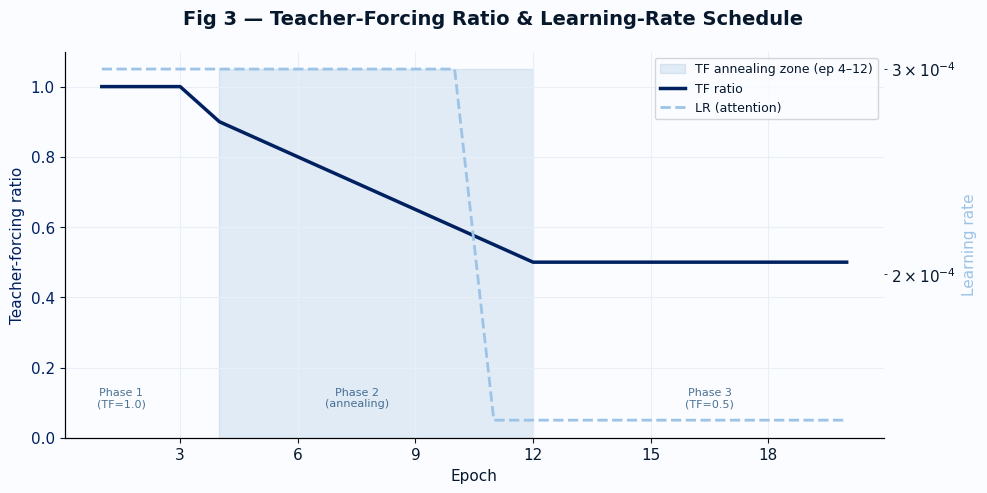

Saved: train_fig3_tf_lr.png


In [11]:
# Fig 3 — TF Ratio + LR Schedule
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.suptitle('Fig 3 \u2014 Teacher-Forcing Ratio & Learning-Rate Schedule', fontsize=14, fontweight='bold')

epochs = list(range(1, N_EPOCHS+1))
tf_vals = [get_tf_ratio(e, CONFIG) for e in epochs]
lrs = attn_h['lrs']

ax1.fill_between(range(4, min(13, N_EPOCHS+1)), 0, 1.05,
                 alpha=0.12, color=PALETTE['attn_val'], label='TF annealing zone (ep 4\u201312)')
ax1.plot(epochs, tf_vals, color=PALETTE['tf_ratio'], lw=2.5, label='TF ratio')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Teacher-forcing ratio', color=PALETTE['tf_ratio'])
ax1.tick_params(axis='y', labelcolor=PALETTE['tf_ratio'])
ax1.set_ylim(0, 1.1)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ylim = ax1.get_ylim()
phase_labels = [
    (1.5,  'Phase 1\n(TF=1.0)'),
    (7.5,  'Phase 2\n(annealing)'),
    (16.5, 'Phase 3\n(TF=0.5)'),
]
for xp, label in phase_labels:
    if xp <= N_EPOCHS:
        ax1.text(xp, ylim[0] + (ylim[1]-ylim[0])*0.08, label,
                 fontsize=8, color=PALETTE['attn_train'], ha='center', alpha=0.8)

ax2 = ax1.twinx()
ax2.plot(epochs, lrs, color=PALETTE['lr'], lw=2, ls='--', label='LR (attention)')
ax2.set_ylabel('Learning rate', color=PALETTE['lr'])
ax2.tick_params(axis='y', labelcolor=PALETTE['lr'])
ax2.set_yscale('log')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'train_fig3_tf_lr.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print("Saved: train_fig3_tf_lr.png")

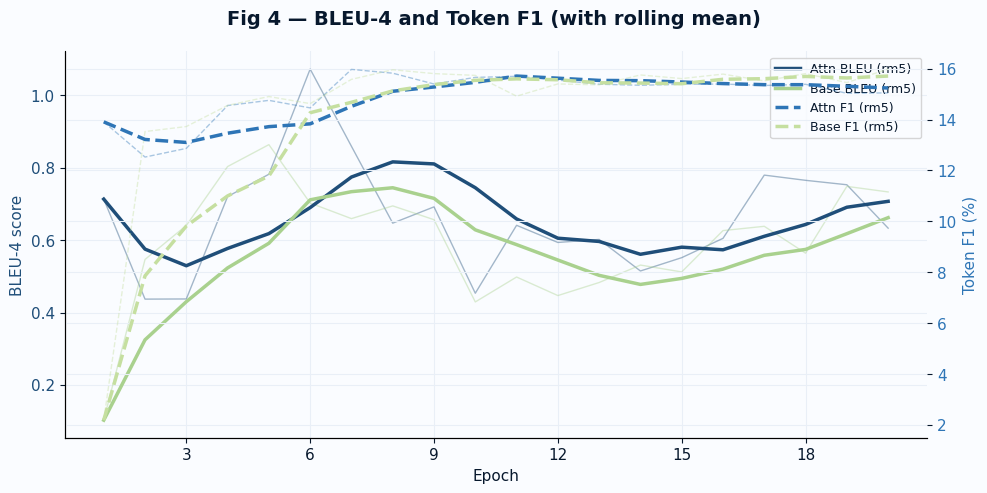

Saved: train_fig4_bleu_f1.png


In [12]:
# Fig 4 — BLEU-4 and Token F1
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.suptitle('Fig 4 \u2014 BLEU-4 and Token F1 (with rolling mean)', fontsize=14, fontweight='bold')

epochs = list(range(1, len(attn_h['bleu'])+1))
window = min(5, len(epochs))

def rolling_mean(vals, w):
    result = []
    for i in range(len(vals)):
        start = max(0, i - w + 1)
        result.append(sum(vals[start:i+1]) / (i - start + 1))
    return result

# Raw values — thin lines
ax1.plot(epochs, attn_h['bleu'], color=PALETTE['bleu'], lw=1.0, alpha=0.4, ls='-')
ax1.plot(epochs, base_h['bleu'], color=PALETTE['base_val'], lw=1.0, alpha=0.4, ls='-')
# Rolling means — bold
ax1.plot(epochs, rolling_mean(attn_h['bleu'], window),
         color=PALETTE['bleu'], lw=2.5, label=f'Attn BLEU (rm{window})')
ax1.plot(epochs, rolling_mean(base_h['bleu'], window),
         color=PALETTE['base_val'], lw=2.5, label=f'Base BLEU (rm{window})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BLEU-4 score', color=PALETTE['bleu'])
ax1.tick_params(axis='y', labelcolor=PALETTE['bleu'])
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

ax2 = ax1.twinx()
ax2.plot(epochs, attn_h['token_f1'], color=PALETTE['f1'], lw=1.0, alpha=0.4, ls='--')
ax2.plot(epochs, base_h['token_f1'], color=PALETTE['base_gen'], lw=1.0, alpha=0.4, ls='--')
ax2.plot(epochs, rolling_mean(attn_h['token_f1'], window),
         color=PALETTE['f1'], lw=2.5, ls='--', label=f'Attn F1 (rm{window})')
ax2.plot(epochs, rolling_mean(base_h['token_f1'], window),
         color=PALETTE['base_gen'], lw=2.5, ls='--', label=f'Base F1 (rm{window})')
ax2.set_ylabel('Token F1 (%)', color=PALETTE['f1'])
ax2.tick_params(axis='y', labelcolor=PALETTE['f1'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'train_fig4_bleu_f1.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print("Saved: train_fig4_bleu_f1.png")

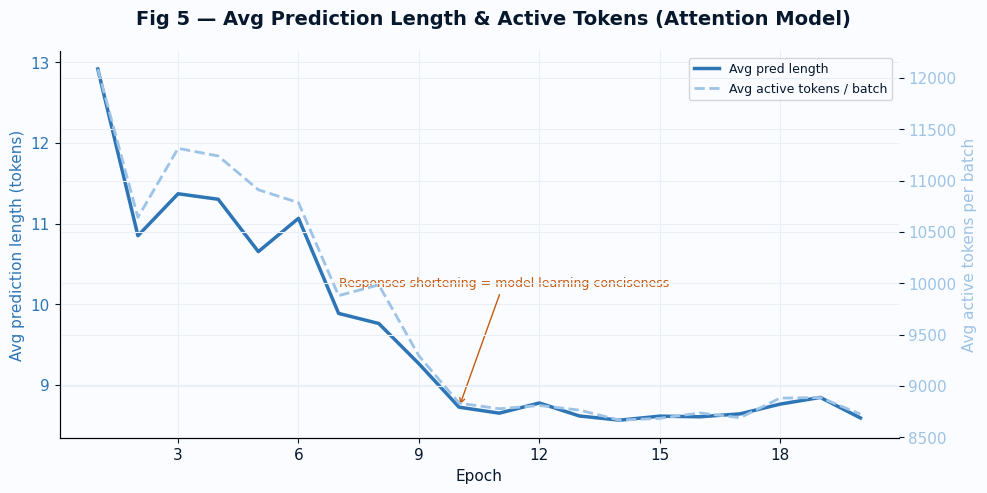

Saved: train_fig5_pred_len.png


In [13]:
# Fig 5 — Prediction Length & Active Tokens
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.suptitle('Fig 5 \u2014 Avg Prediction Length & Active Tokens (Attention Model)', fontsize=14, fontweight='bold')

epochs = list(range(1, len(attn_h['avg_pred_len'])+1))

ax1.plot(epochs, attn_h['avg_pred_len'], color=PALETTE['pred_len'], lw=2.5, label='Avg pred length')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Avg prediction length (tokens)', color=PALETTE['pred_len'])
ax1.tick_params(axis='y', labelcolor=PALETTE['pred_len'])
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

mid_ep = N_EPOCHS // 2
mid_val = attn_h['avg_pred_len'][mid_ep - 1]
ax1.annotate('Responses shortening = model learning conciseness',
             xy=(mid_ep, mid_val),
             xytext=(mid_ep - 3, mid_val + 1.5),
             fontsize=9, color=PALETTE['annot'],
             arrowprops=dict(arrowstyle='->', color=PALETTE['annot']))

ax2 = ax1.twinx()
ax2.plot(epochs, attn_h['avg_active_tokens'], color=PALETTE['active_tok'], lw=2, ls='--',
         label='Avg active tokens / batch')
ax2.set_ylabel('Avg active tokens per batch', color=PALETTE['active_tok'])
ax2.tick_params(axis='y', labelcolor=PALETTE['active_tok'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'train_fig5_pred_len.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print("Saved: train_fig5_pred_len.png")

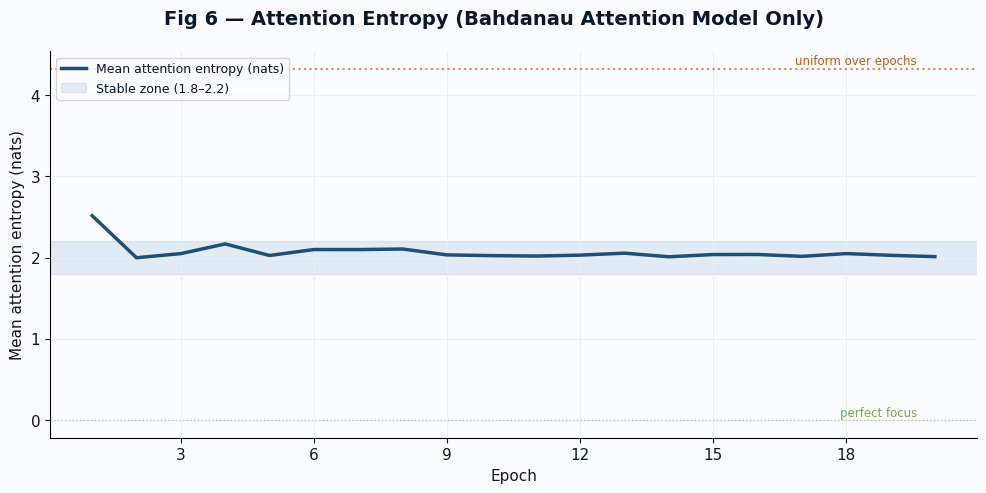

Saved: train_fig6_entropy.png


In [14]:
# Fig 6 — Attention Entropy
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Fig 6 \u2014 Attention Entropy (Bahdanau Attention Model Only)', fontsize=14, fontweight='bold')

epochs = list(range(1, len(attn_h['attn_entropy'])+1))
entropy_vals = [e if e is not None else 0.0 for e in attn_h['attn_entropy']]

ax.plot(epochs, entropy_vals, color=PALETTE['entropy'], lw=2.5, label='Mean attention entropy (nats)')

# Reference lines
uniform_ref = math.log2(N_EPOCHS)
ax.axhline(uniform_ref, color=PALETTE['annot'], lw=1.5, ls=':', alpha=0.7)
ax.text(N_EPOCHS * 0.98, uniform_ref + 0.05, 'uniform over epochs',
        ha='right', fontsize=8.5, color=PALETTE['annot'])

ax.axhline(0, color=PALETTE['base_train'], lw=1.0, ls=':', alpha=0.5)
ax.text(N_EPOCHS * 0.98, 0.05, 'perfect focus',
        ha='right', fontsize=8.5, color=PALETTE['base_train'])

# Stable zone shading
ax.axhspan(1.8, 2.2, alpha=0.12, color=PALETTE['attn_val'], label='Stable zone (1.8\u20132.2)')

ax.set_xlabel('Epoch')
ax.set_ylabel('Mean attention entropy (nats)')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(VIZ_DIR / 'train_fig6_entropy.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print("Saved: train_fig6_entropy.png")

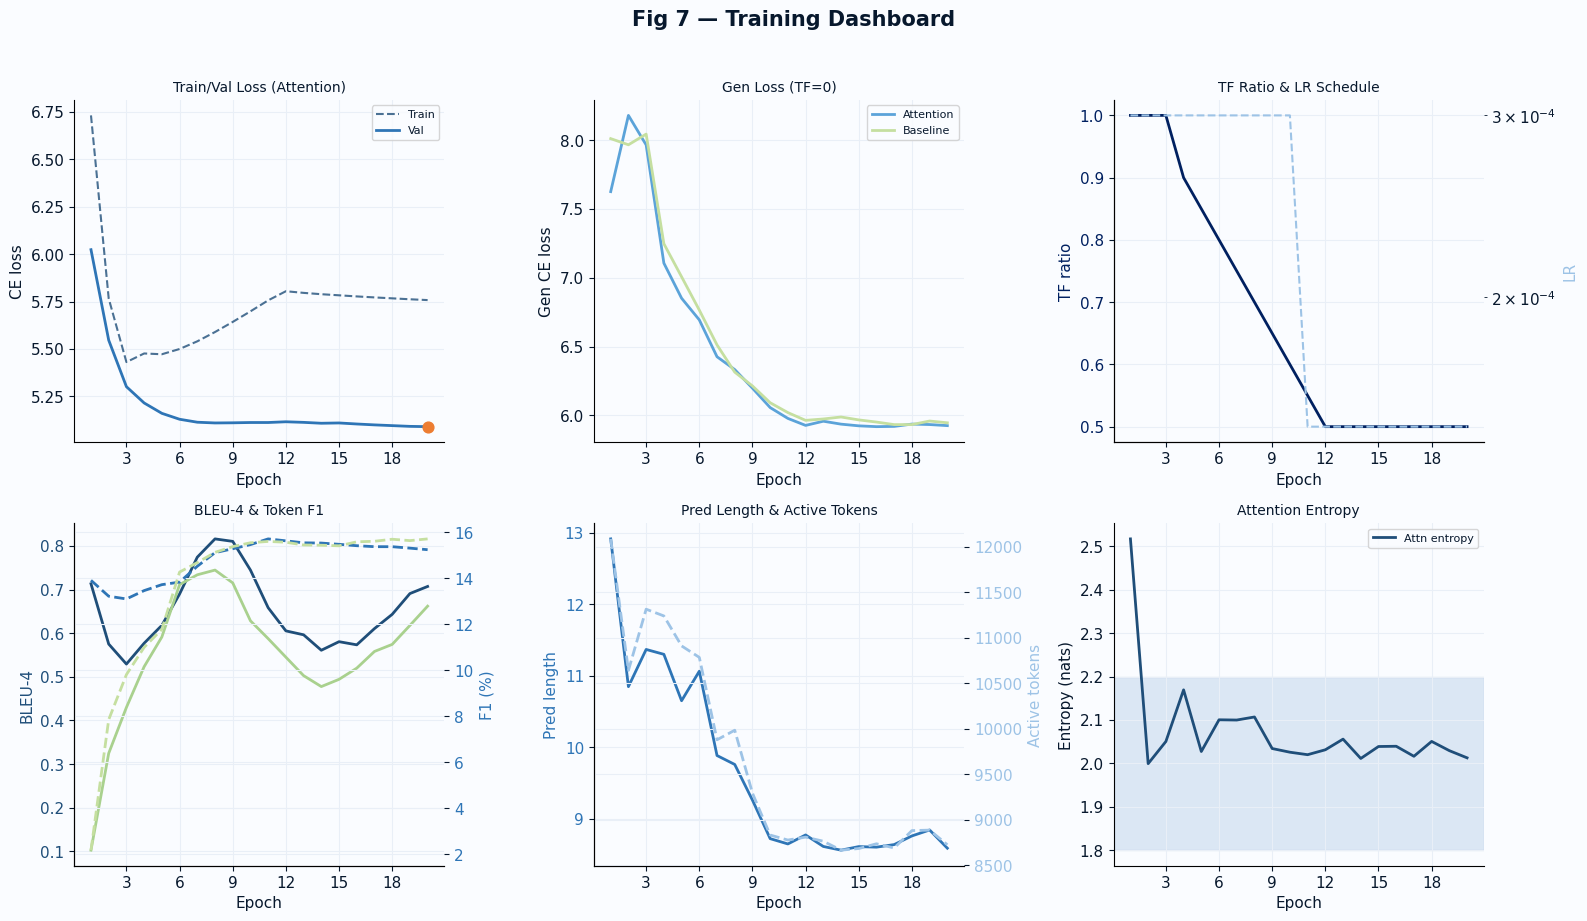

Saved: train_fig7_dashboard.png


In [15]:
# Fig 7 — Dashboard (2x3 grid)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Fig 7 \u2014 Training Dashboard', fontsize=15, fontweight='bold', y=1.02)

epochs = list(range(1, N_EPOCHS+1))
window = min(5, len(epochs))

def rolling_mean(vals, w):
    result = []
    for i in range(len(vals)):
        start = max(0, i - w + 1)
        result.append(sum(vals[start:i+1]) / (i - start + 1))
    return result

# (0,0) Train/Val loss — attention only
ax = axes[0,0]
ax.plot(epochs, attn_h['train_loss'], color=PALETTE['attn_train'], lw=1.5, ls='--', label='Train', alpha=0.8)
ax.plot(epochs, attn_h['val_loss'],   color=PALETTE['attn_val'],   lw=2,   label='Val')
best_i = attn_h['val_loss'].index(min(attn_h['val_loss']))
ax.scatter([best_i+1], [attn_h['val_loss'][best_i]], color=PALETTE['highlight'], s=60, zorder=5)
ax.set_title('Train/Val Loss (Attention)', fontsize=10)
ax.set_xlabel('Epoch'); ax.set_ylabel('CE loss')
ax.legend(fontsize=8); ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# (0,1) Gen loss both models
ax = axes[0,1]
ax.plot(epochs, attn_h['gen_loss'], color=PALETTE['attn_gen'], lw=2, label='Attention')
ax.plot(epochs, base_h['gen_loss'], color=PALETTE['base_gen'], lw=2, label='Baseline')
ax.set_title('Gen Loss (TF=0)', fontsize=10)
ax.set_xlabel('Epoch'); ax.set_ylabel('Gen CE loss')
ax.legend(fontsize=8); ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# (0,2) TF + LR
ax = axes[0,2]
tf_vals = [get_tf_ratio(e, CONFIG) for e in epochs]
ax.plot(epochs, tf_vals, color=PALETTE['tf_ratio'], lw=2, label='TF ratio')
ax.set_xlabel('Epoch'); ax.set_ylabel('TF ratio', color=PALETTE['tf_ratio'])
ax.tick_params(axis='y', labelcolor=PALETTE['tf_ratio'])
ax2_02 = ax.twinx()
ax2_02.plot(epochs, attn_h['lrs'], color=PALETTE['lr'], lw=1.5, ls='--', label='LR')
ax2_02.set_ylabel('LR', color=PALETTE['lr']); ax2_02.tick_params(axis='y', labelcolor=PALETTE['lr'])
ax2_02.set_yscale('log')
ax.set_title('TF Ratio & LR Schedule', fontsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# (1,0) BLEU + F1
ax = axes[1,0]
ax.plot(epochs, rolling_mean(attn_h['bleu'], window), color=PALETTE['bleu'], lw=2, label='Attn BLEU')
ax.plot(epochs, rolling_mean(base_h['bleu'], window), color=PALETTE['base_val'], lw=2, label='Base BLEU')
ax.set_xlabel('Epoch'); ax.set_ylabel('BLEU-4', color=PALETTE['bleu'])
ax.tick_params(axis='y', labelcolor=PALETTE['bleu'])
ax2_10 = ax.twinx()
ax2_10.plot(epochs, rolling_mean(attn_h['token_f1'], window), color=PALETTE['f1'], lw=2, ls='--', label='Attn F1')
ax2_10.plot(epochs, rolling_mean(base_h['token_f1'], window), color=PALETTE['base_gen'], lw=2, ls='--', label='Base F1')
ax2_10.set_ylabel('F1 (%)', color=PALETTE['f1']); ax2_10.tick_params(axis='y', labelcolor=PALETTE['f1'])
ax.set_title('BLEU-4 & Token F1', fontsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# (1,1) Pred len + active tokens
ax = axes[1,1]
ax.plot(epochs, attn_h['avg_pred_len'], color=PALETTE['pred_len'], lw=2, label='Pred len')
ax.set_xlabel('Epoch'); ax.set_ylabel('Pred length', color=PALETTE['pred_len'])
ax.tick_params(axis='y', labelcolor=PALETTE['pred_len'])
ax2_11 = ax.twinx()
ax2_11.plot(epochs, attn_h['avg_active_tokens'], color=PALETTE['active_tok'], lw=2, ls='--', label='Active tokens')
ax2_11.set_ylabel('Active tokens', color=PALETTE['active_tok'])
ax2_11.tick_params(axis='y', labelcolor=PALETTE['active_tok'])
ax.set_title('Pred Length & Active Tokens', fontsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# (1,2) Attention entropy
ax = axes[1,2]
entropy_vals = [e if e is not None else 0.0 for e in attn_h['attn_entropy']]
ax.plot(epochs, entropy_vals, color=PALETTE['entropy'], lw=2, label='Attn entropy')
ax.axhspan(1.8, 2.2, alpha=0.15, color=PALETTE['attn_val'])
ax.set_xlabel('Epoch'); ax.set_ylabel('Entropy (nats)')
ax.set_title('Attention Entropy', fontsize=10)
ax.legend(fontsize=8); ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(VIZ_DIR / 'train_fig7_dashboard.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print("Saved: train_fig7_dashboard.png")

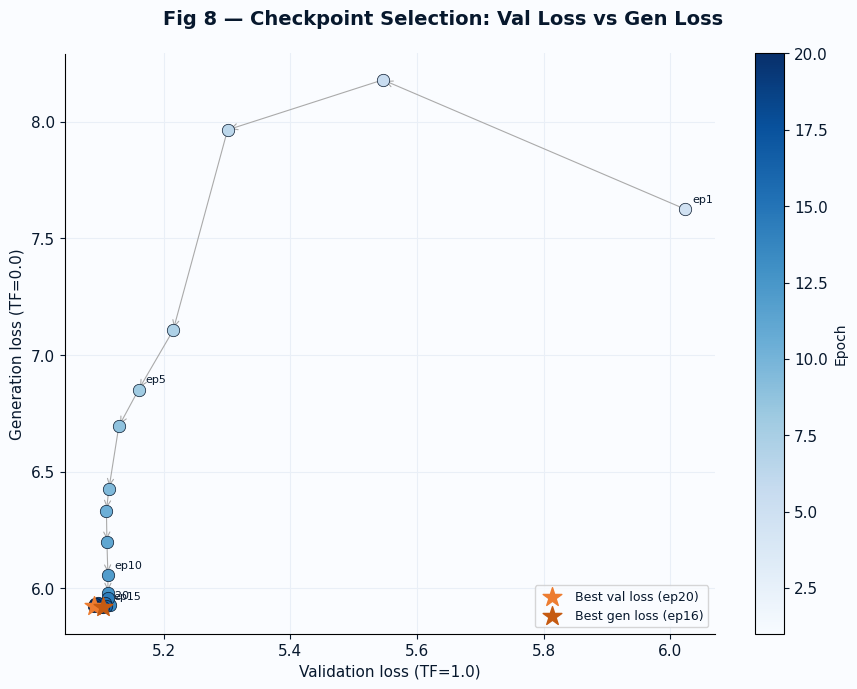

Saved: train_fig8_ckpt_scatter.png


In [16]:
# Fig 8 — Checkpoint Selection Analysis (val_loss vs gen_loss scatter)
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Fig 8 \u2014 Checkpoint Selection: Val Loss vs Gen Loss', fontsize=14, fontweight='bold')

n = len(attn_h['val_loss'])
cmap = plt.cm.Blues
colors = [cmap(0.2 + 0.8 * (i / max(n-1, 1))) for i in range(n)]

for i in range(n):
    ax.scatter(attn_h['val_loss'][i], attn_h['gen_loss'][i],
               color=colors[i], s=80, zorder=5, edgecolors='#07182D', linewidths=0.5)

# Arrows showing training direction
for i in range(n-1):
    dx = attn_h['val_loss'][i+1] - attn_h['val_loss'][i]
    dy = attn_h['gen_loss'][i+1] - attn_h['gen_loss'][i]
    ax.annotate('', xy=(attn_h['val_loss'][i+1], attn_h['gen_loss'][i+1]),
                xytext=(attn_h['val_loss'][i], attn_h['gen_loss'][i]),
                arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=0.8))

# Label every 5th epoch
for i in range(n):
    if (i+1) % 5 == 0 or i == 0:
        ax.annotate(f'ep{i+1}',
                   xy=(attn_h['val_loss'][i], attn_h['gen_loss'][i]),
                   xytext=(5, 5), textcoords='offset points', fontsize=8, color='#07182D')

# Mark best val_loss and best gen_loss
best_val_i = attn_h['val_loss'].index(min(attn_h['val_loss']))
best_gen_i = attn_h['gen_loss'].index(min(attn_h['gen_loss']))
ax.scatter([attn_h['val_loss'][best_val_i]], [attn_h['gen_loss'][best_val_i]],
           color=PALETTE['highlight'], s=200, zorder=8, marker='*',
           label=f'Best val loss (ep{best_val_i+1})')
ax.scatter([attn_h['val_loss'][best_gen_i]], [attn_h['gen_loss'][best_gen_i]],
           color=PALETTE['annot'], s=200, zorder=8, marker='*',
           label=f'Best gen loss (ep{best_gen_i+1})')

# Colorbar for epoch progression
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=n))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Epoch', fontsize=10)

ax.set_xlabel('Validation loss (TF=1.0)')
ax.set_ylabel('Generation loss (TF=0.0)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(VIZ_DIR / 'train_fig8_ckpt_scatter.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close('all')
print("Saved: train_fig8_ckpt_scatter.png")

## Key Findings

In [17]:
# Summary statistics table
best_attn_val_i  = attn_h['val_loss'].index(min(attn_h['val_loss']))
best_base_val_i  = base_h['val_loss'].index(min(base_h['val_loss']))
best_attn_gen_i  = attn_h['gen_loss'].index(min(attn_h['gen_loss']))
best_base_gen_i  = base_h['gen_loss'].index(min(base_h['gen_loss']))

def lr_halving_epoch(lrs):
    return next((i+1 for i in range(1, len(lrs)) if lrs[i] < lrs[i-1]*0.6), None)

attn_lr_ep = lr_halving_epoch(attn_h['lrs'])
base_lr_ep = lr_halving_epoch(base_h['lrs'])

entropy_clean = [e for e in attn_h['attn_entropy'] if e is not None]

attn_bleu_min = min(attn_h['bleu'])
attn_bleu_max = max(attn_h['bleu'])
base_bleu_min = min(base_h['bleu'])
base_bleu_max = max(base_h['bleu'])
attn_f1_min   = min(attn_h['token_f1'])
attn_f1_max   = max(attn_h['token_f1'])
base_f1_min   = min(base_h['token_f1'])
base_f1_max   = max(base_h['token_f1'])

attn_best_val  = min(attn_h['val_loss'])
base_best_val  = min(base_h['val_loss'])
attn_best_gen  = min(attn_h['gen_loss'])
base_best_gen  = min(base_h['gen_loss'])
attn_final_val = attn_h['val_loss'][-1]
base_final_val = base_h['val_loss'][-1]
attn_best_ppl  = math.exp(attn_best_val)
base_best_ppl  = math.exp(base_best_val)
ppl_delta_pct  = (base_best_ppl - attn_best_ppl) / base_best_ppl * 100

print("=" * 66)
print(f"{'Metric':<28} {'Attention':>10}  {'Baseline':>10}  {'\u0394':>8}")
print("\u2500" * 66)
print(f"{'Best val loss':<28} {attn_best_val:>10.4f}  {base_best_val:>10.4f}  {attn_best_val-base_best_val:>+8.3f}")
print(f"{'Best val epoch':<28} {'ep '+str(best_attn_val_i+1):>10}  {'ep '+str(best_base_val_i+1):>10}")
print(f"{'Best gen loss':<28} {attn_best_gen:>10.4f}  {base_best_gen:>10.4f}  {attn_best_gen-base_best_gen:>+8.3f}")
print(f"{'Best gen epoch':<28} {'ep '+str(best_attn_gen_i+1):>10}  {'ep '+str(best_base_gen_i+1):>10}")
print(f"{'Final val loss':<28} {attn_final_val:>10.4f}  {base_final_val:>10.4f}  {attn_final_val-base_final_val:>+8.3f}")
print(f"{'Val PPL (best)':<28} {attn_best_ppl:>10.1f}  {base_best_ppl:>10.1f}  {ppl_delta_pct:>+7.1f}%")
print(f"{'BLEU range':<28} {attn_bleu_min:.2f}\u2013{attn_bleu_max:.2f}  {base_bleu_min:.2f}\u2013{base_bleu_max:.2f}")
print(f"{'Token F1 range':<28} {attn_f1_min:.1f}\u2013{attn_f1_max:.1f}  {base_f1_min:.1f}\u2013{base_f1_max:.1f}")
print(f"{'LR halved':<28} {'epoch '+str(attn_lr_ep) if attn_lr_ep else 'N/A':>10}  {'epoch '+str(base_lr_ep) if base_lr_ep else 'N/A':>10}")
print("\u2500" * 66)
if entropy_clean:
    print(f"\nAttention entropy: min={min(entropy_clean):.3f}  max={max(entropy_clean):.3f}  "
          f"mean={sum(entropy_clean)/len(entropy_clean):.3f} nats")

Metric                        Attention    Baseline         Δ
──────────────────────────────────────────────────────────────────
Best val loss                    5.0898      5.1305    -0.041
Best val epoch                    ep 20       ep 19
Best gen loss                    5.9187      5.9336    -0.015
Best gen epoch                    ep 16       ep 17
Final val loss                   5.0898      5.1312    -0.041
Val PPL (best)                    162.4       169.1     +4.0%
BLEU range                   0.44–1.07  0.10–0.86
Token F1 range               12.5–16.0  2.2–16.0
LR halved                      epoch 11    epoch 12
──────────────────────────────────────────────────────────────────

Attention entropy: min=1.999  max=2.517  mean=2.072 nats


## Next Steps

1. **Inference / deployment** — Load `attention_best.pt` with `build_model()` and wire it to a simple FastAPI endpoint for interactive IRC-style chatbot demo.
2. **Beam search** — Replace greedy decoding in `evaluate_generation()` with beam search (width 4–8) to improve BLEU and reduce repetition in free-form responses.
3. **Fine-tune on hard negatives** — Sample validation pairs where the model's BLEU is lowest; run an additional 5-epoch fine-tune pass to close the generation gap.
4. **Attention visualisation** — Extract per-step `attn_weights` from `AttentionDecoder.forward_step()` on probe questions and plot heatmaps to inspect alignment quality.
5. **Larger vocabulary / model** — Try `vocab_size=64000` and `enc_hidden_dim=768` to see if the attention advantage grows with model capacity.
